# Balanced inference near degeneracy

This notebook reproduces the two-point coverage experiment and the
studentization diagnostics. The balanced design uses edge-disjoint perfect
matchings, so every observation appears equally often.

At exact symmetry, the first Hoeffding projection vanishes although metric
variance remains positive. Complete-pair first-order Wald intervals can then
miss their nominal coverage.

In [1]:
from pathlib import Path
import sys

candidate = Path.cwd().resolve()
if (candidate / "src").is_dir():
    PUBLIC_ROOT = candidate
elif (candidate.parent / "src").is_dir():
    PUBLIC_ROOT = candidate.parent
else:
    raise RuntimeError("Start Jupyter in public or public/notebooks.")

sys.path.insert(0, str(PUBLIC_ROOT / "src"))
DATA_DIR = PUBLIC_ROOT / "data"
print(f"Public package: {PUBLIC_ROOT.name}")

Public package: public


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bmu.simulation_core import near_degenerate_setting

plt.style.use("seaborn-v0_8-whitegrid")
PAPER_SCALE = False

## Archived paper-scale coverage curve

The next cell redraws the manuscript curve from its stored numerical output.
The dotted line marks nominal coverage.

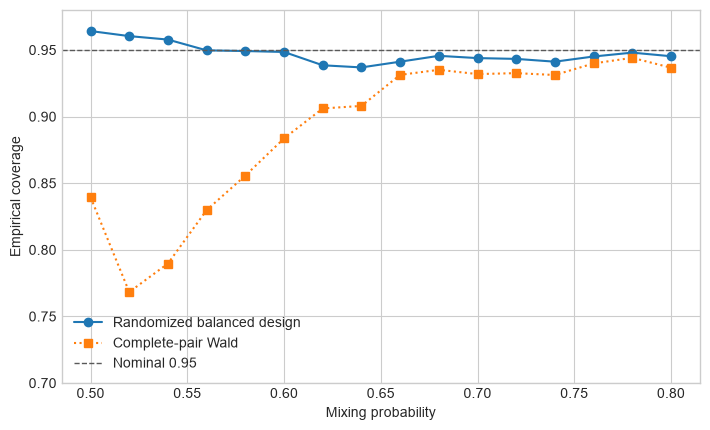

In [3]:
paper_curve = pd.read_csv(DATA_DIR / "simulation_near_degeneracy.csv")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(
    paper_curve["p"],
    paper_curve["balanced_coverage"],
    marker="o",
    label="Randomized balanced design",
)
ax.plot(
    paper_curve["p"],
    paper_curve["complete_wald_coverage"],
    marker="s",
    linestyle=":",
    label="Complete-pair Wald",
)
ax.axhline(0.95, color="0.35", linestyle="--", linewidth=1, label="Nominal 0.95")
ax.set(
    xlabel="Mixing probability",
    ylabel="Empirical coverage",
    ylim=(0.70, 0.98),
)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Fresh simulation

The quick run evaluates a short probability grid. The full option restores the
manuscript grid and repetition count.

In [4]:
if PAPER_SCALE:
    probabilities = np.round(np.arange(0.50, 0.8001, 0.02), 2)
    repetitions = 10_000
else:
    probabilities = np.array([0.50, 0.54, 0.60, 0.70, 0.80])
    repetitions = 800

fresh_rows = [
    near_degenerate_setting(
        n=200,
        k_matchings=12,
        p=float(probability),
        repetitions=repetitions,
        seed=20260713 + index,
    )
    for index, probability in enumerate(probabilities)
]
fresh_curve = pd.DataFrame(fresh_rows)
fresh_curve[
    [
        "p",
        "balanced_coverage",
        "complete_wald_coverage",
        "variance_inflation_percent",
        "repetitions",
    ]
].round(4)

,p,balanced_coverage,complete_wald_coverage,variance_inflation_percent,repetitions
0,0.50,0.9638,0.8338,13.4810,800
1,0.54,0.9625,0.8100,6.5435,800
2,0.60,0.9488,0.8850,-1.2388,800
3,0.70,0.9375,0.9200,-0.1579,800
4,0.80,0.9412,0.9288,-0.0822,800


The complete-pair interval loses its first-order variance at symmetry. The
balanced interval retains the residual pair component and remains usable at
that boundary.

Projection of raw covariance estimates creates finite-sample inflation. The
next tables separate a fixed stress test from a sequence where the theoretical
rate ratio decreases.

In [5]:
stress = pd.read_csv(DATA_DIR / "simulation_studentization_stress.csv")
rate = pd.read_csv(DATA_DIR / "simulation_studentization_rate_sequence.csv")

display(
    stress[
        [
            "model",
            "regime",
            "balanced_coverage",
            "balanced_mean_length",
            "variance_inflation_percent",
        ]
    ].round(4)
)
display(
    rate[
        [
            "n",
            "K",
            "K2_over_sqrt_n",
            "balanced_coverage",
            "scaled_balanced_mean_length",
            "variance_inflation_percent",
        ]
    ].round(4)
)

,model,regime,balanced_coverage,balanced_mean_length,variance_inflation_percent
0,two_point,exact boundary,0.9605,0.1199,12.9962
1,two_point,near boundary,0.9618,0.1209,11.1483
2,Gaussian squared difference,"regular, unbounded",0.9388,0.4050,0.6940


,n,K,K2_over_sqrt_n,balanced_coverage,scaled_balanced_mean_length,variance_inflation_percent
0,200,4,1.1314,0.9533,5.8474,11.5283
1,800,4,0.5657,0.9542,5.6943,5.5805
2,3200,4,0.2828,0.9494,5.6212,2.8351
3,12800,4,0.1414,0.9486,5.5825,1.4131


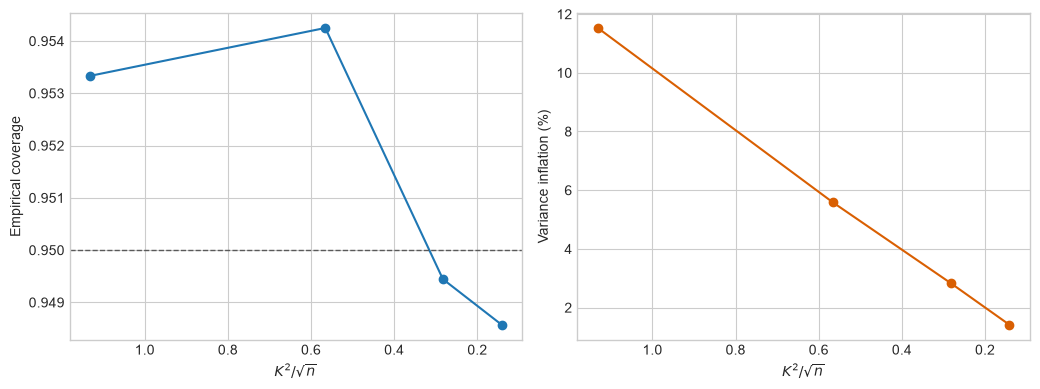

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(rate["K2_over_sqrt_n"], rate["balanced_coverage"], marker="o")
axes[0].axhline(0.95, color="0.35", linestyle="--", linewidth=1)
axes[0].set(
    xlabel=r"$K^2/\sqrt{n}$",
    ylabel="Empirical coverage",
)
axes[1].plot(
    rate["K2_over_sqrt_n"],
    rate["variance_inflation_percent"],
    marker="o",
    color="#d95f02",
)
axes[1].set(
    xlabel=r"$K^2/\sqrt{n}$",
    ylabel="Variance inflation (%)",
)
for axis in axes:
    axis.invert_xaxis()
fig.tight_layout()
plt.show()

Coverage stays near its nominal level as the rate ratio decreases. Variance
inflation also falls, which matches the manuscript's interpretation of the
boundary correction.